# Local Deep Learning Baseline Debug Notebook


Consider the fact that deep learning model is hard to run on the computer, we use this for polit example and adjustment on local machine.

This local version now includes:

- model structure summary and diagram
- fast threshold sweep with CSV export
- experiment summary CSV export

Look for these cells:

- `# Model structure summary and diagram`
- `# Threshold sweep for water probability and experiment CSV export`


In [1]:
# Imports and local environment setup
from pathlib import Path
import os
import random
import time
from dataclasses import asdict, dataclass

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
elif not (PROJECT_DIR / "data").exists() and (PROJECT_DIR / "FinalProjects" / "data").exists():
    PROJECT_DIR = PROJECT_DIR / "FinalProjects"

_MPL_CACHE = PROJECT_DIR / ".cache" / "matplotlib"
_MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_CACHE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

IGNORE_INDEX = -1
NUM_CLASSES = 2

print("Project dir:", PROJECT_DIR)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())


Project dir: /Users/helenxu/Desktop/Spring_2026/musa-650-spring2026-Projects/FinalProjects
Torch: 2.11.0
CUDA available: False
MPS available: True


In [2]:
# Parameters: edit this cell when tuning
DATA_ROOT = PROJECT_DIR / "data" / "sen1floods11_workflow"
OUTPUT_DIR = PROJECT_DIR / "results" / "outputs" / "deep_learning_baseline_local_notebook"


SEED = 42
EPOCHS = 20
BATCH_SIZE = 2
LR = 5e-4
WEIGHT_DECAY = 1e-4
BASE_CHANNELS = 16
NUM_WORKERS = 0

# Use small subsets locally. Set to 0 to use all chips.
MAX_TRAIN_SAMPLES = 80
MAX_VAL_SAMPLES = 40
# Weight modes:
# - "auto": sqrt inverse frequency, usually a stable first try
# - "balanced": full inverse frequency, stronger but can overpredict water
# - "manual": use MANUAL_CLASS_WEIGHTS below
CLASS_WEIGHT_MODE = "auto"
MANUAL_CLASS_WEIGHTS = [1.0, 8.0]  # [non_water, water], only used when mode == "manual"

# If >0, train repeatedly on a tiny subset to check whether the model can overfit.
OVERFIT_BATCHES = 0
AUGMENT = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Data root:", DATA_ROOT)
print("Output dir:", OUTPUT_DIR)


Data root: /Users/helenxu/Desktop/Spring_2026/musa-650-spring2026-Projects/FinalProjects/data/sen1floods11_workflow
Output dir: /Users/helenxu/Desktop/Spring_2026/musa-650-spring2026-Projects/FinalProjects/outputs/deep_learning_baseline_local_notebook


In [3]:
# Reproducibility and device
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)


Device: mps


In [4]:
# Manifest loading
def load_manifest(data_root, max_train, max_val):
    manifest_path = data_root / "manifest.csv"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest: {manifest_path}")

    manifest = pd.read_csv(manifest_path)
    if {"split", "s1_path", "label_path"}.issubset(manifest.columns):
        train_df = manifest[manifest["split"].str.contains("train", case=False, na=False)].copy()
        val_df = manifest[manifest["split"].str.contains("validation|val", case=False, na=False)].copy()
    else:
        manifest = manifest.rename(columns={"s1_alias": "s1_path", "qc_alias": "label_path"})
        train_df = manifest[manifest["s1_path"].str.contains("train", case=False, na=False)].copy()
        val_df = manifest[manifest["s1_path"].str.contains("validation|val", case=False, na=False)].copy()

    if max_train > 0:
        train_df = train_df.sample(min(max_train, len(train_df)), random_state=SEED)
    if max_val > 0:
        val_df = val_df.sample(min(max_val, len(val_df)), random_state=SEED)

    for df in (train_df, val_df):
        df["s1_abs"] = df["s1_path"].apply(lambda p: data_root / p)
        df["label_abs"] = df["label_path"].apply(lambda p: data_root / p)

    missing = []
    all_paths = pd.concat([train_df["s1_abs"], train_df["label_abs"], val_df["s1_abs"], val_df["label_abs"]])
    for path in all_paths:
        if not Path(path).exists():
            missing.append(path)
            if len(missing) >= 5:
                break
    if missing:
        raise FileNotFoundError(f"Manifest contains missing files, examples: {missing}")
    if train_df.empty or val_df.empty:
        raise ValueError(f"Empty split. train={len(train_df)}, val={len(val_df)}")

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

train_df, val_df = load_manifest(DATA_ROOT, MAX_TRAIN_SAMPLES, MAX_VAL_SAMPLES)
print(f"Train chips: {len(train_df)}")
print(f"Val chips: {len(val_df)}")
train_df.head()


Train chips: 80
Val chips: 40


,split,label_source,chip_id,s1_path,label_path,original_s1,original_label,s1_abs,label_abs
0,weak_train_s2index,S2IndexLabelWeak,Colombia_3407621,weak_train_s2index/S1/Colombia_3407621_S1.tif,weak_train_s2index/QC/Colombia_3407621_QC.tif,weak_train_s2index/S1Weak/Colombia_3407621_S1W...,weak_train_s2index/S2IndexLabelWeak/Colombia_3...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...
1,weak_train_s2index,S2IndexLabelWeak,Bolivia_3785326,weak_train_s2index/S1/Bolivia_3785326_S1.tif,weak_train_s2index/QC/Bolivia_3785326_QC.tif,weak_train_s2index/S1Weak/Bolivia_3785326_S1We...,weak_train_s2index/S2IndexLabelWeak/Bolivia_37...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...
2,weak_train_s2index,S2IndexLabelWeak,Colombia_367813,weak_train_s2index/S1/Colombia_367813_S1.tif,weak_train_s2index/QC/Colombia_367813_QC.tif,weak_train_s2index/S1Weak/Colombia_367813_S1We...,weak_train_s2index/S2IndexLabelWeak/Colombia_3...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...
3,weak_train_s2index,S2IndexLabelWeak,Bolivia_7042932,weak_train_s2index/S1/Bolivia_7042932_S1.tif,weak_train_s2index/QC/Bolivia_7042932_QC.tif,weak_train_s2index/S1Weak/Bolivia_7042932_S1We...,weak_train_s2index/S2IndexLabelWeak/Bolivia_70...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...
4,weak_train_s2index,S2IndexLabelWeak,Bolivia_4951438,weak_train_s2index/S1/Bolivia_4951438_S1.tif,weak_train_s2index/QC/Bolivia_4951438_QC.tif,weak_train_s2index/S1Weak/Bolivia_4951438_S1We...,weak_train_s2index/S2IndexLabelWeak/Bolivia_49...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...,/Users/helenxu/Desktop/Spring_2026/musa-650-sp...


In [5]:
# Normalization and Dataset
def normalize_s1(x):
    """Robust per-chip percentile normalization for C x H x W Sentinel-1 input."""
    x = x.astype("float32")
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    out = np.empty_like(x, dtype="float32")
    for band_idx in range(x.shape[0]):
        band = x[band_idx]
        lo, hi = np.percentile(band, [2, 98])
        if hi <= lo:
            out[band_idx] = 0.0
        else:
            out[band_idx] = np.clip((band - lo) / (hi - lo), 0.0, 1.0)
            out[band_idx] = out[band_idx] * 2.0 - 1.0
    return out


class Sen1FloodsDataset(Dataset):
    def __init__(self, frame, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with rasterio.open(row.s1_abs) as src:
            x = src.read([1, 2])
        with rasterio.open(row.label_abs) as src:
            y = src.read(1).astype("int64")

        x = normalize_s1(x)
        y = np.where(np.isin(y, [0, 1]), y, IGNORE_INDEX).astype("int64")

        if self.augment:
            if random.random() < 0.5:
                x = x[:, :, ::-1].copy()
                y = y[:, ::-1].copy()
            if random.random() < 0.5:
                x = x[:, ::-1, :].copy()
                y = y[::-1, :].copy()

        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = Sen1FloodsDataset(train_df, augment=AUGMENT)
val_ds = Sen1FloodsDataset(val_df, augment=False)

x0, y0 = train_ds[0]
print("x:", tuple(x0.shape), x0.dtype, float(x0.min()), float(x0.max()))
print("y:", tuple(y0.shape), y0.dtype, torch.unique(y0))


x: (2, 512, 512) torch.float32 -1.0 1.0
y: (512, 512) torch.int64 tensor([-1,  0,  1])


In [6]:
# Class balance and weighted cross entropy setup
def count_pixels(frame):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for label_path in tqdm(frame["label_abs"], desc="Counting class pixels"):
        with rasterio.open(label_path) as src:
            y = src.read(1)
        counts[0] += int(np.sum(y == 0))
        counts[1] += int(np.sum(y == 1))
    return counts


def make_class_weights(counts, mode, manual):
    if mode == "manual":
        weights = np.array(manual, dtype="float32")
    else:
        freq = counts / counts.sum()
        inv = 1.0 / np.maximum(freq, 1e-8)
        weights = np.sqrt(inv) if mode == "auto" else inv
        weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

class_counts = count_pixels(train_df)
class_freq = class_counts / class_counts.sum()
class_weights = make_class_weights(class_counts, CLASS_WEIGHT_MODE, MANUAL_CLASS_WEIGHTS).to(device)

print("Train valid pixel counts [non_water, water]:", class_counts.tolist())
print("Train class frequency [non_water, water]:", class_freq.round(6).tolist())
print("CE weights [non_water, water]:", class_weights.detach().cpu().numpy().round(4).tolist())


Train valid pixel counts [non_water, water]: [16377163, 1709392]
Train class frequency [non_water, water]: [0.905488, 0.094512]
CE weights [non_water, water]: [0.48840001225471497, 1.5116000175476074]


In [7]:
# DataLoaders
if OVERFIT_BATCHES > 0:
    keep = min(OVERFIT_BATCHES * BATCH_SIZE, len(train_df))
    train_ds = Sen1FloodsDataset(train_df.iloc[:keep], augment=False)
    print(f"Overfit sanity mode: training repeatedly on {keep} chips")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 40
Val batches: 20


In [8]:
# Model: compact U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=2, num_classes=2, base=16):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 4, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)

model = SmallUNet(base=BASE_CHANNELS).to(device)
params_m = sum(p.numel() for p in model.parameters()) / 1e6
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(f"Model parameters: {params_m:.2f}M")


Model parameters: 0.48M


SmallUNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (net): Sequent

,module,type,params,trainable
0,enc1,DoubleConv,2656,2656
1,enc2,DoubleConv,13952,13952
2,enc3,DoubleConv,55552,55552
3,pool,MaxPool2d,0,0
4,bottleneck,DoubleConv,221696,221696
5,up3,ConvTranspose2d,32832,32832
6,dec3,DoubleConv,110848,110848
7,up2,ConvTranspose2d,8224,8224
8,dec2,DoubleConv,27776,27776
9,up1,ConvTranspose2d,2064,2064


Total trainable parameters: 482,610


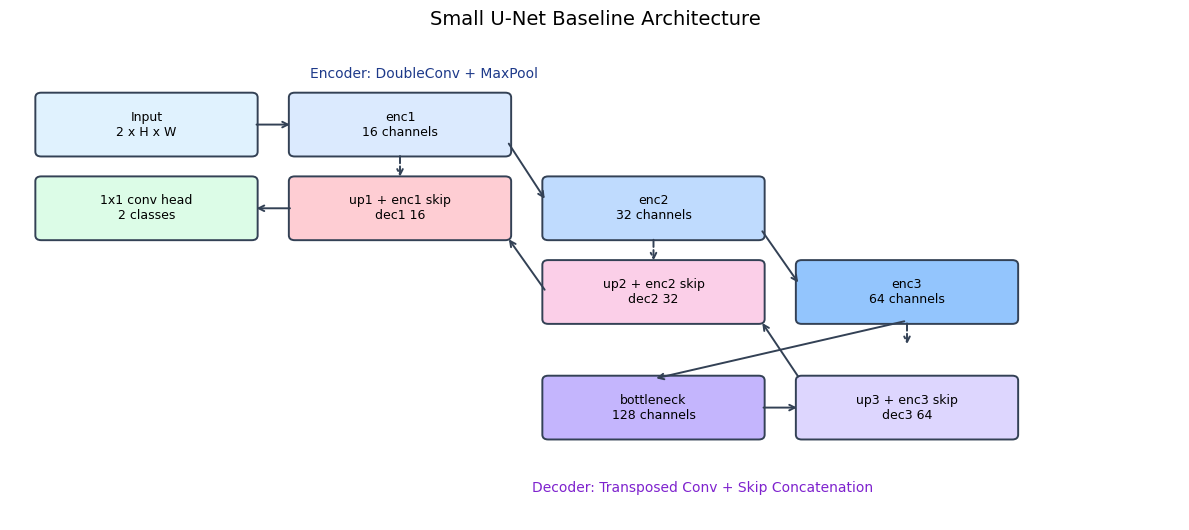

In [9]:
# Model structure summary and diagram
# Run this after the model/reinitialize cell.
from matplotlib.patches import FancyBboxPatch

print(model)

module_rows = []
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    module_rows.append({"module": name, "type": module.__class__.__name__, "params": params, "trainable": trainable})

module_df = pd.DataFrame(module_rows)
display(module_df)
print(f"Total trainable parameters: {module_df['trainable'].sum():,}")


def draw_box(ax, x, y, text, color):
    box = FancyBboxPatch(
        (x, y), 2.2, 0.72,
        boxstyle="round,pad=0.04,rounding_size=0.06",
        linewidth=1.4,
        edgecolor="#334155",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + 1.1, y + 0.36, text, ha="center", va="center", fontsize=9)


def arrow(ax, start, end, dashed=False):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            color="#334155",
            linestyle="--" if dashed else "-",
        ),
    )

fig, ax = plt.subplots(figsize=(12, 5.4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

# Encoder
draw_box(ax, 0.3, 4.6, "Input\n2 x H x W", "#e0f2fe")
draw_box(ax, 2.9, 4.6, f"enc1\n{BASE_CHANNELS} channels", "#dbeafe")
draw_box(ax, 5.5, 3.55, f"enc2\n{BASE_CHANNELS*2} channels", "#bfdbfe")
draw_box(ax, 8.1, 2.5, f"enc3\n{BASE_CHANNELS*4} channels", "#93c5fd")
draw_box(ax, 5.5, 1.05, f"bottleneck\n{BASE_CHANNELS*8} channels", "#c4b5fd")

# Decoder
draw_box(ax, 8.1, 1.05, f"up3 + enc3 skip\ndec3 {BASE_CHANNELS*4}", "#ddd6fe")
draw_box(ax, 5.5, 2.5, f"up2 + enc2 skip\ndec2 {BASE_CHANNELS*2}", "#fbcfe8")
draw_box(ax, 2.9, 3.55, f"up1 + enc1 skip\ndec1 {BASE_CHANNELS}", "#fecdd3")
draw_box(ax, 0.3, 3.55, "1x1 conv head\n2 classes", "#dcfce7")

# Main flow
arrow(ax, (2.5, 4.96), (2.9, 4.96))
arrow(ax, (5.1, 4.75), (5.5, 4.0))
arrow(ax, (7.7, 3.65), (8.1, 2.95))
arrow(ax, (9.2, 2.5), (6.6, 1.77))
arrow(ax, (7.7, 1.41), (8.1, 1.41))
arrow(ax, (8.1, 1.77), (7.7, 2.5))
arrow(ax, (5.5, 2.86), (5.1, 3.55))
arrow(ax, (2.9, 3.91), (2.5, 3.91))

# Skip connections
arrow(ax, (4.0, 4.6), (4.0, 4.27), dashed=True)
arrow(ax, (6.6, 3.55), (6.6, 3.22), dashed=True)
arrow(ax, (9.2, 2.5), (9.2, 2.17), dashed=True)

ax.text(4.25, 5.55, "Encoder: DoubleConv + MaxPool", ha="center", fontsize=10, color="#1e3a8a")
ax.text(7.1, 0.35, "Decoder: Transposed Conv + Skip Concatenation", ha="center", fontsize=10, color="#7e22ce")
ax.set_title("Small U-Net Baseline Architecture", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


In [10]:
# Metrics and train/eval helpers
@dataclass
class Metrics:
    loss: float
    accuracy: float
    water_iou: float
    water_f1: float
    true_water_frac: float
    pred_water_frac: float


def compute_metrics(logits, target, loss):
    pred = logits.argmax(dim=1)
    valid = target != IGNORE_INDEX
    if valid.sum().item() == 0:
        return Metrics(loss, np.nan, np.nan, np.nan, np.nan, np.nan)

    pred_v = pred[valid]
    target_v = target[valid]
    accuracy = (pred_v == target_v).float().mean().item()

    tp = ((pred_v == 1) & (target_v == 1)).sum().item()
    fp = ((pred_v == 1) & (target_v == 0)).sum().item()
    fn = ((pred_v == 0) & (target_v == 1)).sum().item()

    water_iou = tp / (tp + fp + fn + 1e-8)
    water_f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    true_water_frac = (target_v == 1).float().mean().item()
    pred_water_frac = (pred_v == 1).float().mean().item()
    return Metrics(loss, accuracy, water_iou, water_f1, true_water_frac, pred_water_frac)


def average_metrics(items):
    data = pd.DataFrame([asdict(item) for item in items])
    return Metrics(**data.mean(numeric_only=True).to_dict())


def run_epoch(model, loader, criterion, device, optimizer=None, desc=""):
    training = optimizer is not None
    model.train(training)
    metrics = []

    for x, y in tqdm(loader, desc=desc):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = criterion(logits, y)
            if training:
                loss.backward()
                optimizer.step()

        metrics.append(compute_metrics(logits.detach(), y, loss.item()))

    return average_metrics(metrics)


In [15]:
# Reinitialize model
model = SmallUNet(in_channels=2, num_classes=2, base=BASE_CHANNELS).to(device)

# Reinitialize optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Reset tracking
best_iou = -1.0
history = []

best_checkpoint_path = OUTPUT_DIR / "best_small_unet_weighted_ce_run2.pt"
best_quicklook_path = OUTPUT_DIR / "best_val_quicklook_run2.png"

In [19]:
# Train
best_iou = -1.0
history = []
best_checkpoint_path = OUTPUT_DIR / "best_small_unet_weighted_ce.pt"
best_quicklook_path = OUTPUT_DIR / "best_val_quicklook.png"

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_metrics = run_epoch(model, train_loader, criterion, device, optimizer, desc=f"epoch {epoch}/{EPOCHS} train")
    val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None, desc=f"epoch {epoch}/{EPOCHS} val")
    seconds = time.time() - start

    row = {
        "epoch": epoch,
        "seconds": seconds,
        **{f"train_{k}": v for k, v in asdict(train_metrics).items()},
        **{f"val_{k}": v for k, v in asdict(val_metrics).items()},
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics.loss:.4f}, pred water {train_metrics.pred_water_frac:.3f} | "
        f"val loss {val_metrics.loss:.4f}, IoU {val_metrics.water_iou:.3f}, "
        f"F1 {val_metrics.water_f1:.3f}, true water {val_metrics.true_water_frac:.3f}, "
        f"pred water {val_metrics.pred_water_frac:.3f} | {seconds:.1f}s"
    )

    if val_metrics.water_iou > best_iou:
        best_iou = val_metrics.water_iou
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_counts": class_counts.tolist(),
                "class_weights": class_weights.detach().cpu().tolist(),
                "epoch": epoch,
                "val_metrics": asdict(val_metrics),
            },
            best_checkpoint_path,
        )

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "history.csv", index=False)
history_df


Epoch 01 | train loss 0.4760, pred water 0.172 | val loss 0.4909, IoU 0.298, F1 0.386, true water 0.114, pred water 0.232 | 14.9s
Epoch 02 | train loss 0.4002, pred water 0.153 | val loss 0.4353, IoU 0.305, F1 0.395, true water 0.114, pred water 0.152 | 13.4s
Epoch 03 | train loss 0.3806, pred water 0.131 | val loss 0.4243, IoU 0.297, F1 0.387, true water 0.114, pred water 0.123 | 13.5s
Epoch 04 | train loss 0.3724, pred water 0.139 | val loss 0.4225, IoU 0.308, F1 0.395, true water 0.114, pred water 0.158 | 13.1s
Epoch 05 | train loss 0.3565, pred water 0.136 | val loss 0.4216, IoU 0.300, F1 0.390, true water 0.114, pred water 0.131 | 13.4s
Epoch 06 | train loss 0.3655, pred water 0.138 | val loss 0.4258, IoU 0.306, F1 0.397, true water 0.114, pred water 0.162 | 13.6s
Epoch 07 | train loss 0.3433, pred water 0.144 | val loss 0.4595, IoU 0.015, F1 0.029, true water 0.114, pred water 0.005 | 13.2s
Epoch 08 | train loss 0.3343, pred water 0.123 | val loss 0.3999, IoU 0.309, F1 0.399, tru

,epoch,seconds,train_loss,train_accuracy,train_water_iou,train_water_f1,train_true_water_frac,train_pred_water_frac,val_loss,val_accuracy,val_water_iou,val_water_f1,val_true_water_frac,val_pred_water_frac
0,1,14.949802,0.475995,0.851733,0.292629,0.416164,0.093542,0.172036,0.490879,0.813475,0.297721,0.386292,0.113628,0.231541
1,2,13.366147,0.400205,0.871411,0.310098,0.440859,0.093720,0.152528,0.435254,0.873338,0.305171,0.395066,0.113628,0.151912
2,3,13.488296,0.380596,0.878543,0.290987,0.423608,0.093590,0.131268,0.424254,0.890171,0.296656,0.387058,0.113628,0.123330
3,4,13.102007,0.372442,0.878006,0.313170,0.436862,0.093752,0.138917,0.422507,0.869931,0.308401,0.395432,0.113628,0.158487
4,5,13.447510,0.356531,0.881342,0.328987,0.459504,0.090617,0.135730,0.421615,0.886554,0.300248,0.389869,0.113628,0.131085
5,6,13.559429,0.365503,0.874762,0.319510,0.440380,0.096038,0.138235,0.425752,0.866902,0.305713,0.396592,0.113628,0.161510
6,7,13.236888,0.343270,0.881024,0.339488,0.466129,0.097941,0.144401,0.459462,0.889431,0.015302,0.028629,0.113628,0.004780
7,8,13.087053,0.334327,0.887638,0.334565,0.459563,0.092964,0.122510,0.399939,0.868960,0.308744,0.398509,0.113628,0.161120
8,9,13.402866,0.344618,0.881093,0.324591,0.455761,0.096240,0.136456,0.412163,0.883242,0.280953,0.376943,0.113628,0.121783
9,10,12.972603,0.349825,0.881451,0.321647,0.451003,0.092657,0.125596,0.388370,0.905781,0.271771,0.365062,0.113628,0.086231


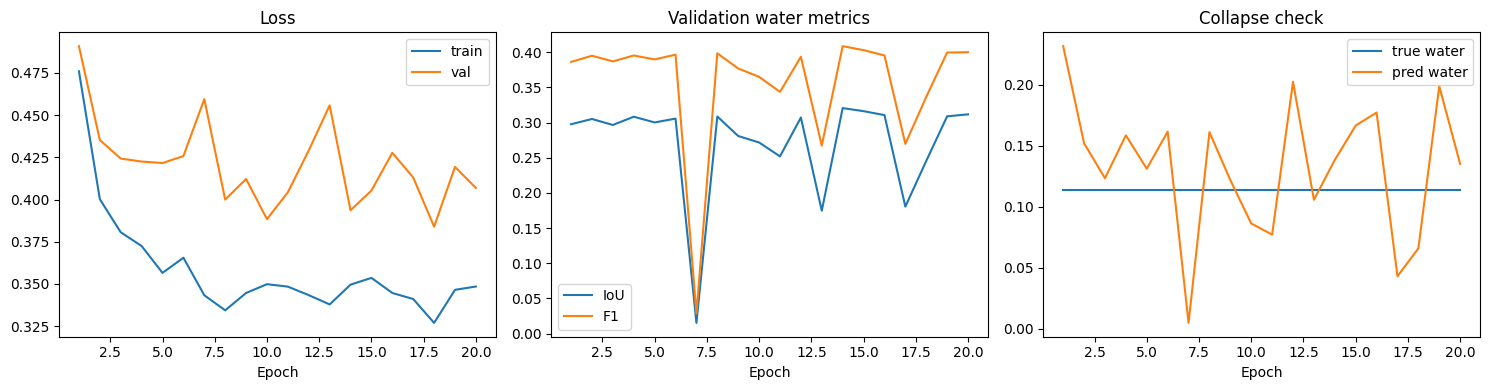

In [20]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_water_iou"], label="IoU")
axes[1].plot(history_df["epoch"], history_df["val_water_f1"], label="F1")
axes[1].set_title("Validation water metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["val_true_water_frac"], label="true water")
axes[2].plot(history_df["epoch"], history_df["val_pred_water_frac"], label="pred water")
axes[2].set_title("Collapse check")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()


In [ ]:
# Threshold sweep for water probability and experiment CSV export
# This caches validation probabilities once, then scans thresholds quickly.
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_probs = []
all_targets = []
losses = []

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="cache validation probabilities"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        losses.append(criterion(logits, y).item())
        prob_water = torch.softmax(logits, dim=1)[:, 1].detach().cpu()
        all_probs.append(prob_water.reshape(-1))
        all_targets.append(y.detach().cpu().reshape(-1))

probs = torch.cat(all_probs)
targets = torch.cat(all_targets)
valid = targets != IGNORE_INDEX
probs = probs[valid]
targets = targets[valid]

thresholds = np.linspace(0.05, 0.95, 19)
stats = []
for threshold in thresholds:
    pred = (probs >= threshold).long()
    tp = int(((pred == 1) & (targets == 1)).sum().item())
    fp = int(((pred == 1) & (targets == 0)).sum().item())
    fn = int(((pred == 0) & (targets == 1)).sum().item())
    tn = int(((pred == 0) & (targets == 0)).sum().item())
    iou = tp / (tp + fp + fn + 1e-8)
    f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    stats.append({
        "experiment": "threshold_sweep_existing_best",
        "threshold": float(threshold),
        "val_loss": float(np.mean(losses)),
        "iou_water": iou,
        "f1_water": f1,
        "precision": precision,
        "recall": recall,
        "true_water_frac": float((targets == 1).float().mean().item()),
        "pred_water_frac": float((pred == 1).float().mean().item()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "checkpoint_epoch": checkpoint.get("epoch"),
        "base_channels": BASE_CHANNELS,
        "class_weight_0": float(class_weights.detach().cpu()[0]),
        "class_weight_1": float(class_weights.detach().cpu()[1]),
    })

threshold_df = pd.DataFrame(stats)
threshold_path = OUTPUT_DIR / "threshold_sweep.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold sweep:", threshold_path)
display(threshold_df.sort_values("iou_water", ascending=False).head(10))

# Compact experiment summary for reporting.
history_path = OUTPUT_DIR / "history.csv"
history_for_summary = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame(history)
best_history = history_for_summary.loc[history_for_summary["val_water_iou"].idxmax()]
best_threshold = threshold_df.loc[threshold_df["iou_water"].idxmax()]

experiment_summary = pd.DataFrame([
    {
        "experiment": "local_weighted_ce_batch_avg_argmax",
        "epochs_run": int(history_for_summary["epoch"].max()),
        "best_epoch": int(best_history["epoch"]),
        "decision_rule": "argmax / batch-averaged metrics",
        "threshold": 0.50,
        "val_iou_water": float(best_history["val_water_iou"]),
        "val_f1_water": float(best_history["val_water_f1"]),
        "val_accuracy": float(best_history["val_accuracy"]),
        "val_true_water_frac": float(best_history["val_true_water_frac"]),
        "val_pred_water_frac": float(best_history["val_pred_water_frac"]),
        "notes": "Existing notebook training metric; averages IoU/F1 per batch.",
    },
    {
        "experiment": "local_weighted_ce_global_threshold",
        "epochs_run": int(history_for_summary["epoch"].max()),
        "best_epoch": int(checkpoint.get("epoch", best_history["epoch"])),
        "decision_rule": "softmax water threshold / global confusion",
        "threshold": float(best_threshold["threshold"]),
        "val_iou_water": float(best_threshold["iou_water"]),
        "val_f1_water": float(best_threshold["f1_water"]),
        "val_accuracy": np.nan,
        "val_true_water_frac": float(best_threshold["true_water_frac"]),
        "val_pred_water_frac": float(best_threshold["pred_water_frac"]),
        "notes": "Recommended validation readout; computes confusion over all valid pixels.",
    },
])
summary_path = OUTPUT_DIR / "experiment_summary.csv"
experiment_summary.to_csv(summary_path, index=False)
print("Saved experiment summary:", summary_path)
display(experiment_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(threshold_df["threshold"], threshold_df["iou_water"], marker="o", label="IoU")
axes[0].plot(threshold_df["threshold"], threshold_df["f1_water"], marker="o", label="F1")
axes[0].axvline(best_threshold["threshold"], color="black", linestyle="--", label="best IoU threshold")
axes[0].set_xlabel("Water probability threshold")
axes[0].legend()
axes[0].set_title("Threshold vs metrics")

axes[1].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
axes[1].plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
axes[1].plot(threshold_df["threshold"], threshold_df["pred_water_frac"], marker="o", label="pred water frac")
axes[1].axhline(threshold_df["true_water_frac"].iloc[0], color="black", linestyle="--", label="true water frac")
axes[1].set_xlabel("Water probability threshold")
axes[1].legend()
axes[1].set_title("Precision/recall balance")
plt.tight_layout()


Saved quicklook: /Users/helenxu/Desktop/Spring_2026/musa-650-spring2026-Projects/FinalProjects/outputs/deep_learning_baseline_local_notebook/best_val_quicklook.png


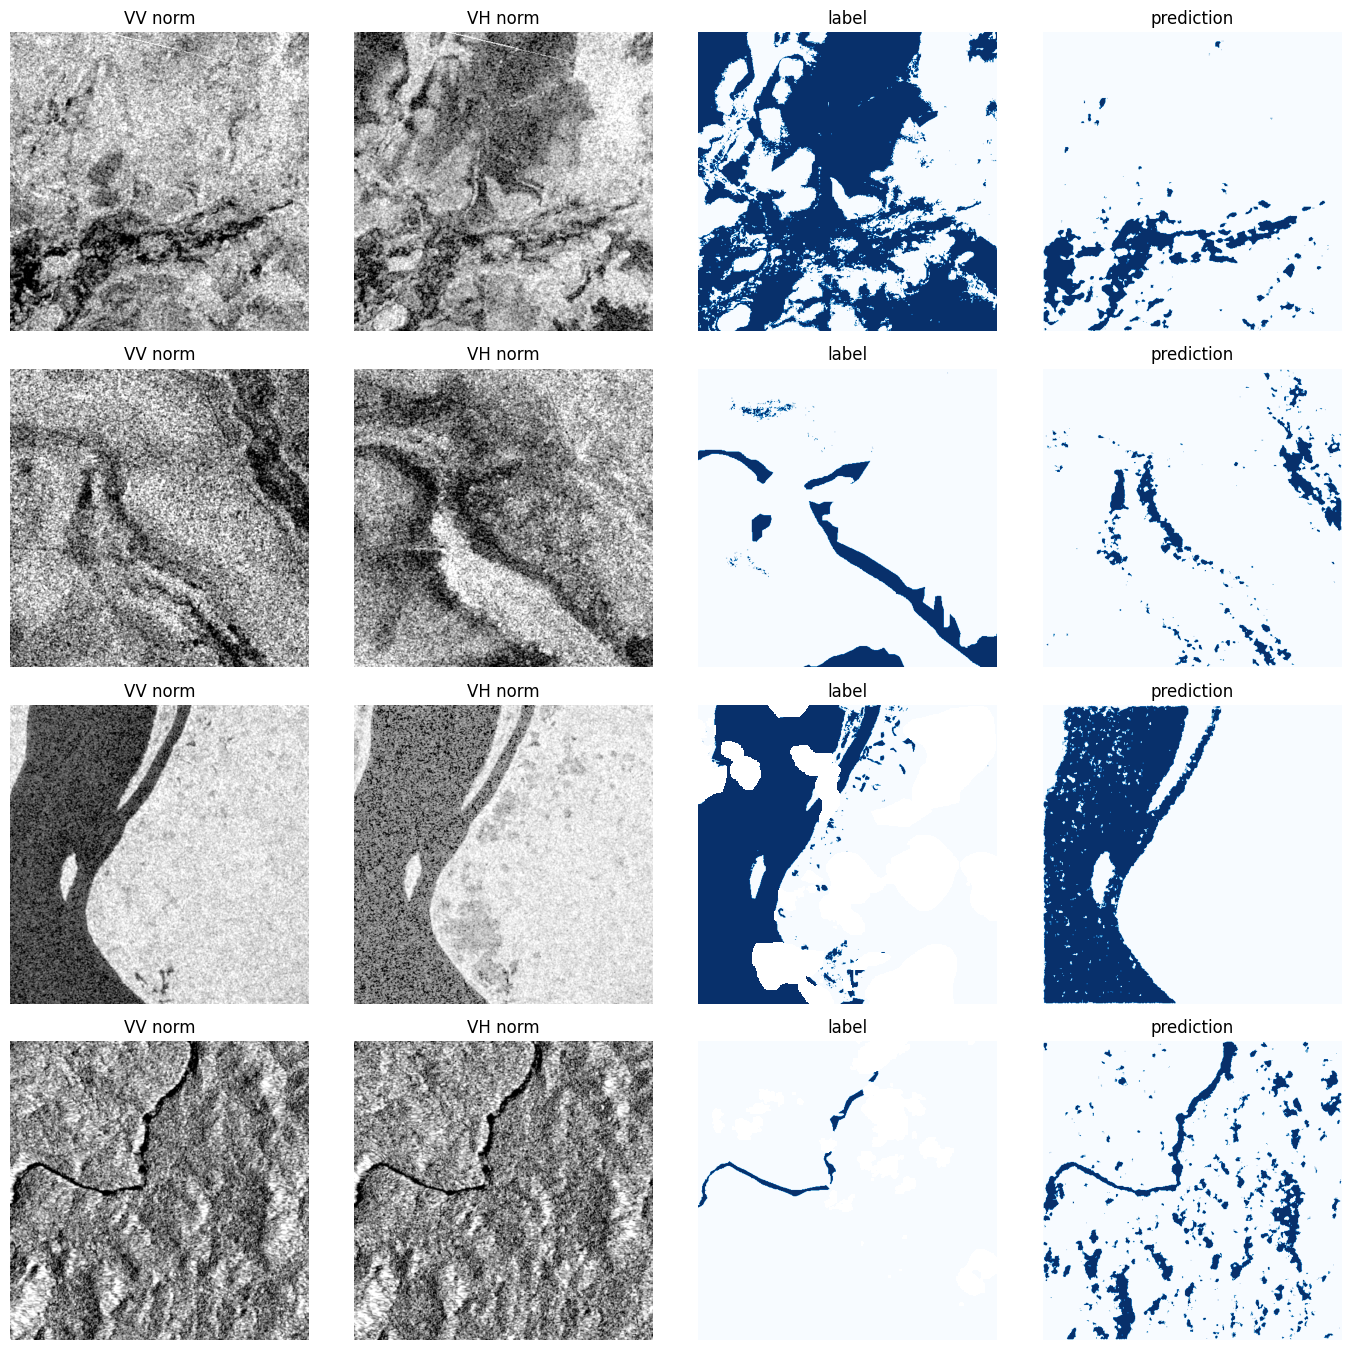

In [21]:
# Visualize validation predictions and save quicklook
model.eval()
n_show = min(4, len(val_ds))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.4 * n_show), squeeze=False)

for idx in range(n_show):
    x, y = val_ds[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu().numpy()
    label = y.numpy()
    label_plot = np.ma.masked_where(label == IGNORE_INDEX, label)

    axes[idx, 0].imshow(x[0].numpy(), cmap="gray")
    axes[idx, 0].set_title("VV norm")
    axes[idx, 1].imshow(x[1].numpy(), cmap="gray")
    axes[idx, 1].set_title("VH norm")
    axes[idx, 2].imshow(label_plot, cmap="Blues", vmin=0, vmax=1)
    axes[idx, 2].set_title("label")
    axes[idx, 3].imshow(pred, cmap="Blues", vmin=0, vmax=1)
    axes[idx, 3].set_title("prediction")

    for ax in axes[idx]:
        ax.axis("off")

fig.tight_layout()
fig.savefig(best_quicklook_path, dpi=160)
print("Saved quicklook:", best_quicklook_path)


In [22]:
# Suggested tuning presets
print("If pred water is still near 0.000, try:")
print("CLASS_WEIGHT_MODE = 'manual'; MANUAL_CLASS_WEIGHTS = [1.0, 8.0]")
print("or CLASS_WEIGHT_MODE = 'balanced'")
print()
print("If pred water is too high everywhere, reduce the water weight, e.g. [1.0, 3.0].")
print("For sanity checking, set OVERFIT_BATCHES = 4 and EPOCHS = 20; the model should overfit that tiny subset.")


If pred water is still near 0.000, try:
CLASS_WEIGHT_MODE = 'manual'; MANUAL_CLASS_WEIGHTS = [1.0, 8.0]
or CLASS_WEIGHT_MODE = 'balanced'

If pred water is too high everywhere, reduce the water weight, e.g. [1.0, 3.0].
For sanity checking, set OVERFIT_BATCHES = 4 and EPOCHS = 20; the model should overfit that tiny subset.
